In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
from pathlib import Path
from PIL import Image
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torchmetrics import JaccardIndex
from tqdm import tqdm
from torch.utils.data import random_split
import zipfile
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [2]:
seed = 42
torch.random.manual_seed(seed)

device = "cuda" if torch.cuda.is_available() else "cpu"

ROOT_PATH = "/home/stefan/ioai-prep/kits/contest/glitch"
BATCH_SIZE = 8
IMG_SIZE = 512

# Data

In [ ]:
class BinarySegmentationDataset(Dataset):
    def __init__(self, root_path: str, is_train: bool = True):
        self.is_train = is_train
        self.root_path = Path(root_path) / ("train" if is_train else "test")
        self.image_paths = sorted((self.root_path / "images").glob("*.png"))
        self.mask_dir = self.root_path / "masks"

        self.augment = transforms.Compose(
            [
                transforms.ColorJitter(
                    brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1
                ),
                transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
            ]
        )

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        image = transforms.Resize((IMG_SIZE, IMG_SIZE))(image)

        if self.is_train:
            mask_filename = img_path.name.replace("img_", "mask_")
            mask_path = self.mask_dir / mask_filename
            mask = Image.open(mask_path).convert("L")
            mask = transforms.Resize((IMG_SIZE, IMG_SIZE))(mask)

            # Random rotation (90 degree multiples)
            k = torch.randint(0, 4, (1,)).item()
            image = transforms.functional.rotate(image, k * 90)
            mask = transforms.functional.rotate(mask, k * 90)

            # Flips
            if torch.rand(1) < 0.5:
                image = transforms.functional.hflip(image)
                mask = transforms.functional.hflip(mask)
            if torch.rand(1) < 0.5:
                image = transforms.functional.vflip(image)
                mask = transforms.functional.vflip(mask)

            # Color augmentation
            if torch.rand(1) < 0.7:
                image = self.augment(image)

            image = transforms.ToTensor()(image)
            mask = transforms.ToTensor()(mask)
            mask = (mask > 0.5).float()
            return image, mask
        else:
            image = transforms.ToTensor()(image)
            return image

    def __len__(self):
        return len(self.image_paths)

In [4]:
train_dataset = BinarySegmentationDataset(
    ROOT_PATH, is_train=True
)

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(
    train_dataset, [train_size, val_size]
)

train_dataloader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4,
    pin_memory=True
)

val_dataloader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4,
    pin_memory=True
)

test_dataset = BinarySegmentationDataset(
    ROOT_PATH, is_train=False
)
test_dataloader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4,
    pin_memory=True
)

In [5]:
# sanity check
x = next(iter(train_dataloader))
[b.shape for b in x]

[torch.Size([8, 3, 512, 512]), torch.Size([8, 1, 512, 512])]

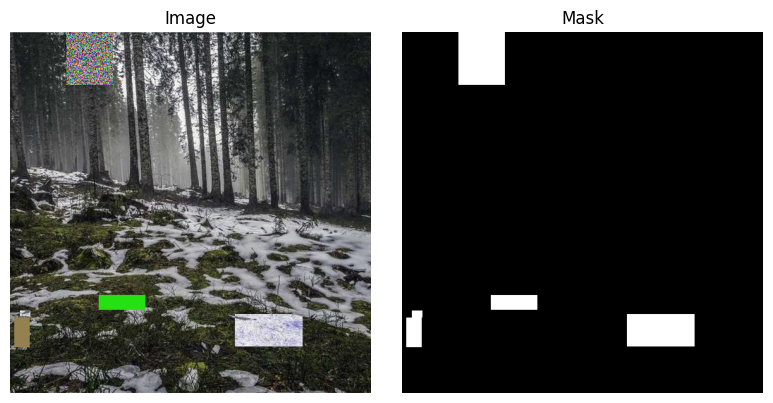

In [6]:
images, masks = next(iter(train_dataloader))

idx = 1
img = images[idx].permute(1, 2, 0).cpu()
mask = masks[idx].squeeze().cpu()

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(img)
ax[0].set_title("Image")
ax[0].axis("off")

ax[1].imshow(mask, cmap="gray")
ax[1].set_title("Mask")
ax[1].axis("off")

plt.tight_layout()
plt.show()

# Model

In [7]:
class UNet(nn.Module):
    def __init__(self, in_channels: int = 3, out_channels: int = 1):
        super().__init__()

        # encoder
        self.enc1 = self._conv_block(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = self._conv_block(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = self._conv_block(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = self._conv_block(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        # bottleneck
        self.bottleneck = self._conv_block(512, 1024)

        # decoder
        self.upconv4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = self._conv_block(1024, 512)
        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = self._conv_block(512, 256)
        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = self._conv_block(256, 128)
        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = self._conv_block(128, 64)

        # output
        self.final = nn.Conv2d(64, out_channels, kernel_size=1)

    def _conv_block(self, in_channels: int, out_channels: int):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.3),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.3),
        )

    def forward(self, x):
        enc1 = self.enc1(x)
        enc2 = self.enc2(self.pool1(enc1))
        enc3 = self.enc3(self.pool2(enc2))
        enc4 = self.enc4(self.pool3(enc3))

        bottleneck = self.bottleneck(self.pool4(enc4))

        dec4 = self.dec4(torch.cat([self.upconv4(bottleneck), enc4], dim=1))
        dec3 = self.dec3(torch.cat([self.upconv3(dec4), enc3], dim=1))
        dec2 = self.dec2(torch.cat([self.upconv2(dec3), enc2], dim=1))
        dec1 = self.dec1(torch.cat([self.upconv1(dec2), enc1], dim=1))

        out = self.final(dec1)
        return out

In [8]:
model = UNet(in_channels=3, out_channels=1).to(device)

model(x[0].to(device)).shape

torch.Size([8, 1, 512, 512])

# Training

In [9]:
class DiceLoss(nn.Module):
    def __init__(self, smooth: float = 1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        pred_flat = pred.reshape(-1)
        target_flat = target.reshape(-1)

        intersection = (pred_flat * target_flat).sum()
        dice = (2.0 * intersection + self.smooth) / (
            pred_flat.sum() + target_flat.sum() + self.smooth
        )
        return 1.0 - dice


class DiceBCELoss(nn.Module):
    def __init__(self, smooth: float = 1.0, bce_weight: float = 0.3):
        super().__init__()
        self.dice_loss = DiceLoss(smooth=smooth)
        self.bce_loss = nn.BCEWithLogitsLoss()
        self.bce_weight = bce_weight
        self.dice_weight = 1.0 - bce_weight

    def forward(self, pred, target):
        dice = self.dice_loss(torch.sigmoid(pred) > 0.5, target)
        bce = self.bce_loss(pred, target)
        return self.dice_weight * dice + self.bce_weight * bce

In [10]:
scaler = torch.amp.GradScaler("cuda")

def train_epoch(dataloader, model, criterion, optimizer, device, iou_metric):
    model.train()
    total_loss = 0.0
    total_iou = 0.0

    for images, masks in tqdm(dataloader, desc="Training"):
        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()
        with torch.amp.autocast("cuda", dtype=torch.bfloat16):
            outputs = model(images)
            loss = criterion(outputs, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

        # IoU calculation
        preds_binary = (outputs > 0.5).float()
        iou = iou_metric(preds_binary, masks)
        total_iou += iou.item()

    avg_loss = total_loss / len(dataloader)
    avg_iou = total_iou / len(dataloader)

    return avg_loss, avg_iou

In [11]:
def val_epoch(dataloader, model, criterion, device, iou_metric):
    model.eval()
    total_loss = 0.0
    total_iou = 0.0

    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc="Validation"):
            images, masks = images.to(device), masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)
            total_loss += loss.item()

            preds_binary = (outputs > 0.5).float()
            iou = iou_metric(preds_binary, masks)
            total_iou += iou.item()
    
    avg_loss = total_loss / len(dataloader)
    avg_iou = total_iou / len(dataloader)

    return avg_loss, avg_iou

In [64]:
model.load_state_dict(torch.load("unet.pt"))

<All keys matched successfully>

In [65]:
class IoULoss(nn.Module):
    def __init__(self, smooth: float = 1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        pred = torch.sigmoid(pred)
        intersection = (pred * target).sum()
        union = pred.sum() + target.sum() - intersection
        iou = (intersection + self.smooth) / (union + self.smooth)
        return 1.0 - iou

In [108]:
num_epochs = 5
lr = 1e-4

criterion = IoULoss()
optimizer = AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
iou_metric = JaccardIndex(task="binary").to(device)

In [109]:
for epoch in range(num_epochs):
    iou_metric.reset()
    train_loss, train_iou = train_epoch(
        train_dataloader, model, criterion, optimizer, device, iou_metric
    )
    iou_metric.reset()
    val_loss, val_iou = val_epoch(
        val_dataloader, model, criterion, device, iou_metric
    )

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | Train IoU: {train_iou:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val IoU: {val_iou:.4f}"
    )

Validation: 100%|██████████| 5/5 [00:01<00:00,  3.91it/s]


Epoch 1/5 | Train Loss: 0.0871 | Train IoU: 0.9171 | Val Loss: 0.0958 | Val IoU: 0.9079


Validation: 100%|██████████| 5/5 [00:01<00:00,  3.43it/s]


Epoch 2/5 | Train Loss: 0.0810 | Train IoU: 0.9231 | Val Loss: 0.1172 | Val IoU: 0.8880


Validation: 100%|██████████| 5/5 [00:01<00:00,  3.73it/s]


Epoch 3/5 | Train Loss: 0.0844 | Train IoU: 0.9189 | Val Loss: 0.1223 | Val IoU: 0.8814


Validation: 100%|██████████| 5/5 [00:01<00:00,  3.56it/s]


Epoch 4/5 | Train Loss: 0.0784 | Train IoU: 0.9251 | Val Loss: 0.1043 | Val IoU: 0.8997


Validation: 100%|██████████| 5/5 [00:01<00:00,  3.55it/s]

Epoch 5/5 | Train Loss: 0.0799 | Train IoU: 0.9238 | Val Loss: 0.0970 | Val IoU: 0.9064


In [110]:
# torch.save(model.state_dict(), "unet-iou.pt")

# Submission

In [111]:
def find_best_threshold():
    model.eval()
    best_iou = 0
    best_threshold = 0.5

    with torch.no_grad():
        for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
            total_iou = 0
            for images, masks in val_dataloader:
                images, masks = images.to(device), masks.to(device)
                outputs = torch.sigmoid(model(images))
                preds = (outputs > threshold).float()
                iou = iou_metric(preds, masks)
                total_iou += iou.item()

            avg_iou = total_iou / len(val_dataloader)
            if avg_iou > best_iou:
                best_iou = avg_iou
                best_threshold = threshold

    return best_threshold

thresh = find_best_threshold()
thresh

0.4

In [112]:
import cv2

def fit_rectangle_to_mask(mask_tensor, min_area_ratio=0.001):
    mask_np = (mask_tensor.squeeze().cpu().numpy() * 255).astype(np.uint8)

    # Find all contours
    contours, _ = cv2.findContours(mask_np, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return torch.zeros_like(mask_tensor)

    # Calculate minimum area threshold
    total_area = mask_np.shape[0] * mask_np.shape[1]
    min_area = total_area * min_area_ratio

    # Create perfect rectangle mask
    rect_mask = np.zeros_like(mask_np)

    # Draw all significant rectangles
    for contour in contours:
        area = cv2.contourArea(contour)
        if area >= min_area:
            x, y, w, h = cv2.boundingRect(contour)
            rect_mask[y : y + h, x : x + w] = 255

    return torch.from_numpy(rect_mask / 255.0).unsqueeze(0).float()

In [113]:
def generate_submission(
    model,
    test_dataloader,
    test_dataset,
    device,
    output_dir="submission",
    zip_name=f"{ROOT_PATH}/submission.zip",
):
    model.eval()
    output_path = Path(output_dir)
    output_path.mkdir(exist_ok=True)

    with torch.no_grad():
        for idx, images in enumerate(tqdm(test_dataloader)):
            images = images.to(device)
            outputs = torch.sigmoid(model(images))
            preds_binary = (outputs > thresh).float()

            for batch_idx, pred in enumerate(preds_binary):
                rect_pred = fit_rectangle_to_mask(pred)
                # rect_pred = pred
                pred_np = rect_pred.cpu().squeeze().numpy()
                pred_255 = (pred_np * 255).astype(np.uint8)

                global_idx = idx * BATCH_SIZE + batch_idx
                original_path = test_dataset.image_paths[global_idx]

                img = Image.fromarray(pred_255, mode="L")
                img.save(output_path / original_path.name)

    with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as zf:
        for file in output_path.glob("*.png"):
            zf.write(file, arcname=file.name)

In [114]:
generate_submission(model, test_dataloader, test_dataset, device)

 12%|█▏        | 3/25 [00:01<00:08,  2.55it/s]


KeyboardInterrupt: 